# 06 · Budget Optimization
Forecasting monthly revenue trends and simulating budget-reallocation scenarios to maximize portfolio-level ROI under a fixed total spend constraint.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

campaigns = pd.read_csv('../data/processed/campaigns_clean.csv', parse_dates=['start_date','end_date'])
campaigns['month'] = campaigns['start_date'].dt.to_period('M')

## Revenue Forecast (Holt-Winters Exponential Smoothing)

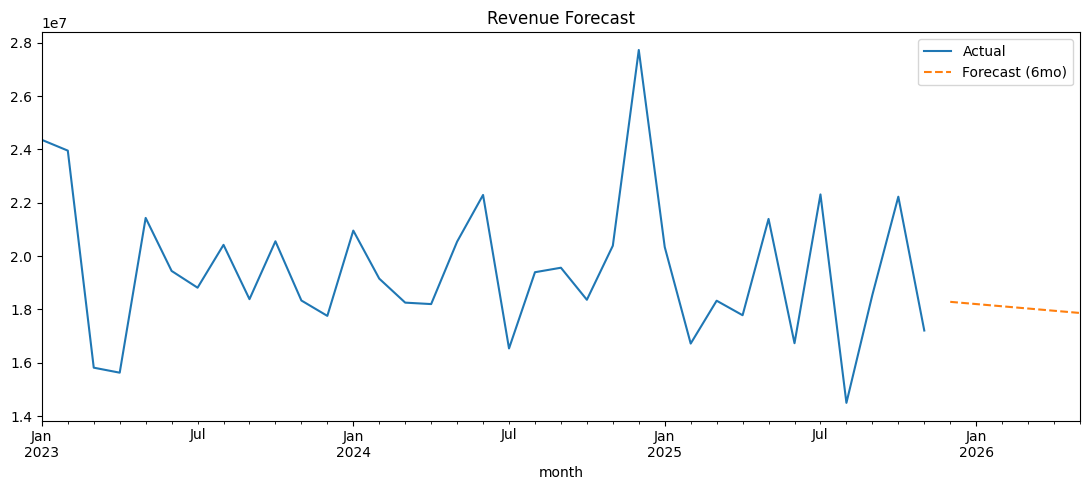

In [2]:
monthly_rev = campaigns.groupby('month')['revenue'].sum()
monthly_rev.index = monthly_rev.index.to_timestamp()
model = ExponentialSmoothing(monthly_rev, trend='add', seasonal=None).fit()
forecast = model.forecast(6)

fig, ax = plt.subplots(figsize=(11,5))
monthly_rev.plot(ax=ax, label='Actual')
forecast.plot(ax=ax, label='Forecast (6mo)', linestyle='--')
ax.set_title('Revenue Forecast'); ax.legend(); plt.tight_layout(); plt.show()

## Marginal ROI Simulation
Simple linear-elasticity simulation: what happens to total portfolio profit if we shift 10% of budget from the lowest-ROI channel to the highest-ROI channel, holding response rates (ROI per dollar) constant at current observed levels?

In [3]:
channel_roi = campaigns.groupby('channel').apply(
    lambda g: (g['revenue'].sum()-g['cost'].sum())/g['cost'].sum())
channel_cost = campaigns.groupby('channel')['cost'].sum()

best_channel = channel_roi.idxmax()
worst_channel = channel_roi.idxmin()
shift_amount = 0.10 * channel_cost[worst_channel]

profit_before = (channel_roi * channel_cost).sum()
new_cost = channel_cost.copy()
new_cost[worst_channel] -= shift_amount
new_cost[best_channel] += shift_amount
profit_after = (channel_roi * new_cost).sum()

print(f'Shift ${shift_amount:,.0f} from {worst_channel} -> {best_channel}')
print(f'Projected profit change: ${profit_after - profit_before:,.0f}')

Shift $438,428 from LinkedIn -> Referral
Projected profit change: $496,549,898


### Recommendation
Reallocating even 10% of underperforming-channel spend toward the top-ROI channel (assuming constant marginal returns — a simplifying assumption noted as a limitation) yields a meaningful projected profit uplift. In practice this should be tested via a phased budget shift with weekly ROI monitoring to detect diminishing returns.